# Scaling Law Analysis

This notebook plots the scaling law curves for three GNN architectures (GAT, GCN, GIN) showing how test accuracy varies with the fraction of training data used.

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)
sns.set_palette("husl")

# Enhanced font settings for electronic publication
plt.rcParams['figure.dpi'] = 150  # Higher DPI for screen display
plt.rcParams['savefig.dpi'] = 600  # Publication quality (600 DPI for electronic)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.format'] = 'png'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

In [9]:
# Base paths for each model
base_paths = {
    'GAT': Path('/home/jeff/ribozyme/results/scaling_law_gat'),
    'GCN': Path('/home/jeff/ribozyme/results/scaling_law_gcn'),
    'GIN': Path('/home/jeff/ribozyme/results/scaling_law_gin')
}

# Data fractions to analyze
fractions = [0.1, 0.2, 0.4, 0.8, 1.0]

In [10]:
def extract_final_val_acc(history_path):
    """Extract the final validation accuracy from history.json"""
    with open(history_path, 'r') as f:
        history = json.load(f)
    # Return the last validation accuracy
    return history['val_acc'][-1]

def collect_results(base_path, model_name):
    """Collect validation accuracies for all fractions and seeds"""
    results = defaultdict(list)
    
    for exp_dir in base_path.iterdir():
        if not exp_dir.is_dir():
            continue
        
        # Parse directory name: scaling_law_{model}_frac{frac}_seed{seed}_{timestamp}
        dir_name = exp_dir.name
        if not dir_name.startswith(f'scaling_law_{model_name.lower()}'):
            continue
        
        # Extract fraction from directory name
        for frac in fractions:
            if f'frac{frac}' in dir_name:
                history_path = exp_dir / 'history.json'
                if history_path.exists():
                    val_acc = extract_final_val_acc(history_path)
                    results[frac].append(val_acc)
                break
    
    return results

In [11]:
# Collect results for all models
all_results = {}
for model_name, base_path in base_paths.items():
    all_results[model_name] = collect_results(base_path, model_name)
    print(f"\n{model_name} Results:")
    for frac in fractions:
        accs = all_results[model_name][frac]
        if accs:
            print(f"  Fraction {frac}: {len(accs)} seeds, mean={np.mean(accs):.4f}, std={np.std(accs):.4f}")
        else:
            print(f"  Fraction {frac}: No data")


GAT Results:
  Fraction 0.1: 3 seeds, mean=0.6390, std=0.0021
  Fraction 0.2: 3 seeds, mean=0.6784, std=0.0038
  Fraction 0.4: 3 seeds, mean=0.7452, std=0.0103
  Fraction 0.8: 3 seeds, mean=0.7920, std=0.0041
  Fraction 1.0: 5 seeds, mean=0.8053, std=0.0314

GCN Results:
  Fraction 0.1: 3 seeds, mean=0.7015, std=0.0063
  Fraction 0.2: 3 seeds, mean=0.7524, std=0.0026
  Fraction 0.4: 3 seeds, mean=0.8154, std=0.0157
  Fraction 0.8: 3 seeds, mean=0.8677, std=0.0040
  Fraction 1.0: 3 seeds, mean=0.8751, std=0.0074

GIN Results:
  Fraction 0.1: 3 seeds, mean=0.7589, std=0.0131
  Fraction 0.2: 3 seeds, mean=0.8039, std=0.0075
  Fraction 0.4: 3 seeds, mean=0.8634, std=0.0068
  Fraction 0.8: 3 seeds, mean=0.9175, std=0.0062
  Fraction 1.0: 3 seeds, mean=0.9188, std=0.0047


In [12]:
# Compute mean and std for each model and fraction
plot_data = {}
for model_name in ['GAT', 'GCN', 'GIN']:
    means = []
    stds = []
    valid_fractions = []
    
    for frac in fractions:
        accs = all_results[model_name][frac]
        if accs:
            means.append(np.mean(accs))
            stds.append(np.std(accs))
            valid_fractions.append(frac)
    
    plot_data[model_name] = {
        'fractions': valid_fractions,
        'means': means,
        'stds': stds
    }

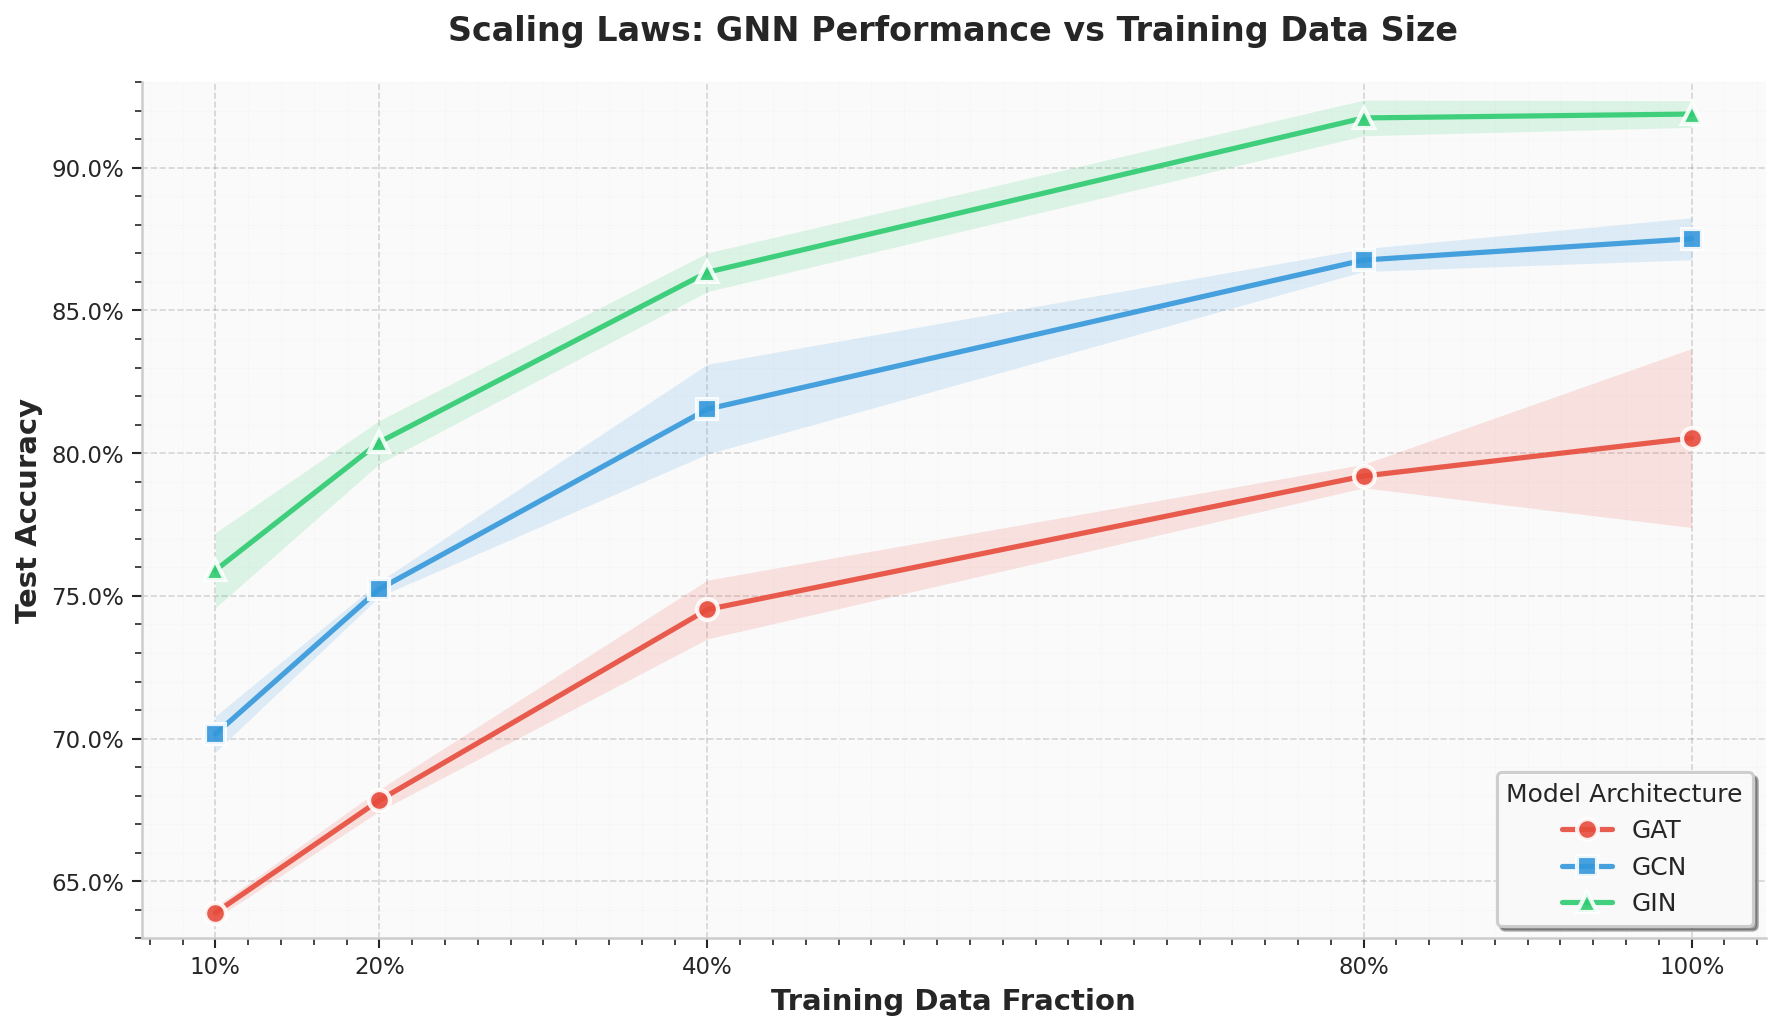

Figure saved as 'scaling_law_plot.png' at 600 DPI


In [19]:
# Create the scaling law plot with enhanced aesthetics
fig, ax = plt.subplots(figsize=(12, 7))

# Use a professional color palette
colors = {
    'GAT': '#E74C3C',  # Red
    'GCN': '#3498DB',  # Blue
    'GIN': '#2ECC71'   # Green
}
markers = {'GAT': 'o', 'GCN': 's', 'GIN': '^'}

for model_name in ['GAT', 'GCN', 'GIN']:
    data = plot_data[model_name]
    fracs = np.array(data['fractions'])
    means = np.array(data['means'])
    stds = np.array(data['stds'])
    
    # Plot line with markers
    ax.plot(fracs, means, 
            label=model_name, 
            color=colors[model_name],
            marker=markers[model_name],
            markersize=10,
            linewidth=2.5,
            alpha=0.9,
            markeredgewidth=2,
            markeredgecolor='white')
    
    # Add shaded error region (±1 std)
    ax.fill_between(fracs, 
                     means - stds, 
                     means + stds,
                     color=colors[model_name],
                     alpha=0.15,
                     linewidth=0)

# Formatting
ax.set_xlabel('Training Data Fraction', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Scaling Laws: GNN Performance vs Training Data Size', 
             fontsize=16, fontweight='bold', pad=20)

# Set y-axis limits for better visualization
ax.set_ylim(0.63, 0.93)

# Better x-axis formatting
ax.set_xticks(fractions)
ax.set_xticklabels([f'{int(f*100)}%' for f in fractions])

# Format y-axis as percentage using FuncFormatter (fixes the warning)
def percent_formatter(y, pos):
    return f'{y:.1%}'

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

# Enhanced grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)

# Legend with frame
legend = ax.legend(fontsize=12, 
                   loc='lower right',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   title='Model Architecture',
                   title_fontsize=12)
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_linewidth(1.5)

# Add subtle background color
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

# Add minor gridlines for better readability
ax.minorticks_on()
ax.grid(which='minor', alpha=0.15, linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

# Save high-resolution figure for publication
fig.savefig('/home/jeff/ribozyme/notebooks/scaling_law_plot.png', 
            dpi=800, 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
print("Figure saved as 'scaling_law_plot.png' at 600 DPI")

In [20]:
# Print summary statistics
print("\n" + "="*60)
print("SCALING LAW SUMMARY")
print("="*60)

for model_name in ['GAT', 'GCN', 'GIN']:
    print(f"\n{model_name}:")
    data = plot_data[model_name]
    for frac, mean, std in zip(data['fractions'], data['means'], data['stds']):
        print(f"  {frac*100:5.1f}% data: {mean:.4f} ± {std:.4f}")
    
    if len(data['means']) > 1:
        improvement = data['means'][-1] - data['means'][0]
        print(f"  Improvement (10% → 100%): {improvement:.4f} ({improvement/data['means'][0]*100:.1f}%)")


SCALING LAW SUMMARY

GAT:
   10.0% data: 0.6390 ± 0.0021
   20.0% data: 0.6784 ± 0.0038
   40.0% data: 0.7452 ± 0.0103
   80.0% data: 0.7920 ± 0.0041
  100.0% data: 0.8053 ± 0.0314
  Improvement (10% → 100%): 0.1663 (26.0%)

GCN:
   10.0% data: 0.7015 ± 0.0063
   20.0% data: 0.7524 ± 0.0026
   40.0% data: 0.8154 ± 0.0157
   80.0% data: 0.8677 ± 0.0040
  100.0% data: 0.8751 ± 0.0074
  Improvement (10% → 100%): 0.1736 (24.7%)

GIN:
   10.0% data: 0.7589 ± 0.0131
   20.0% data: 0.8039 ± 0.0075
   40.0% data: 0.8634 ± 0.0068
   80.0% data: 0.9175 ± 0.0062
  100.0% data: 0.9188 ± 0.0047
  Improvement (10% → 100%): 0.1599 (21.1%)
